<a href="https://colab.research.google.com/github/rawalnidhi/ai-investment-trends-analysis/blob/main/notebooks/AI_Investment_Trends_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Investment Trends and Company Valuations (2014–2025)

## Project Overview

This project analyzes funding trends among AI companies between 2014 and 2025. The goal is to examine how investment in artificial intelligence has evolved over time and explore the relationship between funding and company valuation.

The analysis was conducted using Python, Pandas, NumPy, and Matplotlib for data exploration and visualization.

### Research Question

How has investment in AI companies changed over time, and what relationship exists between funding and company valuation?

### Visualizations

1. Top 10 AI Companies by Funding Raised (Bar Plot)
2. Total AI Funding by Year (Line Plot)
3. Funding vs. Post-Money Valuation (Scatter Plot)

In [21]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots within the notebook
%matplotlib inline

# Load Dataset

The dataset contains information about AI company funding events, including funding amounts, company valuations, investment rounds, and company characteristics.

In [22]:
# Load dataset

df = pd.read_csv('ai_startup_funding_database_2014_2025.csv')

# Display first five records
df.head()

,company,deal_date,round_type,amount_usd_millions,pre_money_valuation_millions,post_money_valuation_millions,lead_investors,other_investors,sector,subsector,...,ipo_status,key_products,open_source,source,year,quarter,month,deal_size_tier,is_us_company,stage_number
0,DeepMind,2014-01-26,Acquisition,500,NaN,NaN,Google (acquirer),NaN,Foundation Model / Research,AI Research Lab,...,Acquired by Google,"AlphaFold, Gemini, AlphaGo",True,"The Information, Google",2014,1,1,Large ($500M+),False,0
1,OpenAI,2019-07-22,Strategic Investment,1000,NaN,NaN,Microsoft,None disclosed,Foundation Model / LLM,General-Purpose AI,...,Private,"GPT-2, OpenAI Five",True,Microsoft blog,2019,3,7,Unicorn ($1B+),True,8
2,Palantir,2020-09-30,Direct Listing,0,NaN,15800.0,Public Market (NYSE),NaN,AI Application,Data Analytics / Defense AI,...,Public (NYSE: PLTR),"Foundry, Gotham, AIP",False,SEC filing,2020,3,9,Early (<$100M),True,10
3,UiPath,2021-04-21,IPO,1340,NaN,35800.0,Public Market (NYSE),"Morgan Stanley, JPMorgan, BofA",AI Application,Robotic Process Automation,...,Public (NYSE: PATH),"UiPath Platform, AI Center",False,SEC S-1 filing,2021,2,4,Unicorn ($1B+),True,10
4,SenseTime,2021-12-20,IPO,740,NaN,16800.0,Public Market (HKEX),"Cornerstone: CITIC, CICC, HAO Capital",AI Application,Computer Vision / Smart City,...,Public (HKEX: 0020),"SenseCore, facial recognition, autonomous driving",False,HKEX filings,2021,4,12,Large ($500M+),False,10


# Initial Data Exploration

The following steps examine the structure of the dataset, identify missing values, and verify data types before analysis.

In [23]:
# Dataset dimensions

print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns:
(38, 27)

Column Names:
['company', 'deal_date', 'round_type', 'amount_usd_millions', 'pre_money_valuation_millions', 'post_money_valuation_millions', 'lead_investors', 'other_investors', 'sector', 'subsector', 'hq_city', 'hq_country', 'founded_year', 'ceo', 'employees_approx', 'annual_revenue_millions', 'profitable', 'ipo_status', 'key_products', 'open_source', 'source', 'year', 'quarter', 'month', 'deal_size_tier', 'is_us_company', 'stage_number']


In [24]:
# Check data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        38 non-null     object 
 1   deal_date                      38 non-null     object 
 2   round_type                     38 non-null     object 
 3   amount_usd_millions            38 non-null     int64  
 4   pre_money_valuation_millions   28 non-null     float64
 5   post_money_valuation_millions  31 non-null     float64
 6   lead_investors                 38 non-null     object 
 7   other_investors                36 non-null     object 
 8   sector                         38 non-null     object 
 9   subsector                      38 non-null     object 
 10  hq_city                        38 non-null     object 
 11  hq_country                     38 non-null     object 
 12  founded_year                   38 non-null     int64

In [25]:
# Summary statistics for numerical variables

df.describe()

,amount_usd_millions,pre_money_valuation_millions,post_money_valuation_millions,founded_year,employees_approx,annual_revenue_millions,year,quarter,month,stage_number
count,38.000000,28.000000,31.000000,38.000000,38.000000,25.00000,38.000000,38.000000,38.000000,38.000000
mean,4093.263158,45879.642857,48103.225806,2018.052632,1351.710526,1644.68000,2023.500000,2.473684,6.447368,5.210526
std,7083.857602,68054.906685,71243.135266,5.135712,1865.806932,2507.94527,2.226984,1.058731,3.374766,2.772041
min,0.000000,900.000000,1000.000000,2003.000000,30.000000,11.00000,2014.000000,1.000000,1.000000,0.000000
25%,500.000000,3948.750000,5250.000000,2015.000000,250.000000,150.00000,2023.000000,2.000000,4.000000,3.250000
50%,1670.000000,18250.000000,20000.000000,2019.000000,475.000000,850.00000,2024.000000,2.000000,6.000000,5.000000
75%,4750.000000,42250.000000,40400.000000,2022.000000,1375.000000,1900.00000,2025.000000,3.000000,9.000000,7.000000
max,40000.000000,260000.000000,300000.000000,2025.000000,7000.000000,11600.00000,2025.000000,4.000000,12.000000,10.000000


In [26]:
# Check for missing values

df.isnull().sum()

,0
company,0
deal_date,0
round_type,0
amount_usd_millions,0
pre_money_valuation_millions,10
post_money_valuation_millions,7
lead_investors,0
other_investors,2
sector,0
subsector,0


# Visualization 1: Top 10 AI Companies by Total Funding Raised

This visualization identifies the AI companies that have raised the largest cumulative amount of funding in the dataset. By aggregating funding across all investment rounds, we can determine which organizations have attracted the greatest investor interest.

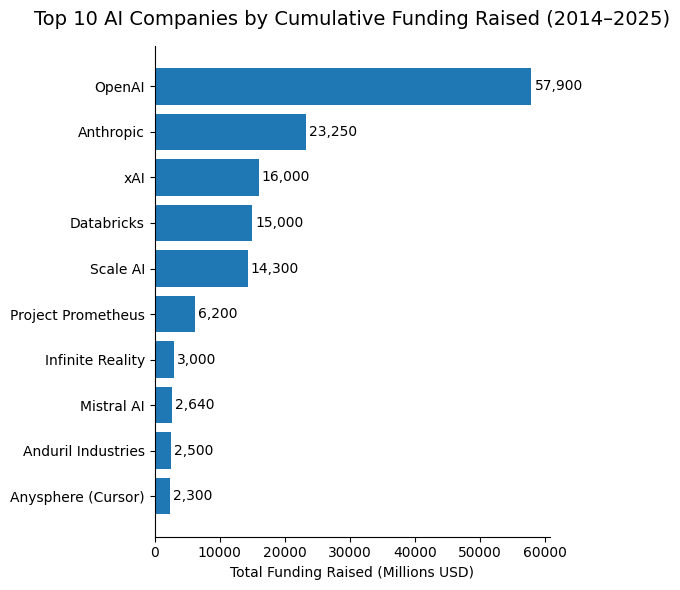

In [27]:
# Aggregate total funding by company

top_companies = (
    df.groupby('company')['amount_usd_millions']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Create figure

plt.figure(figsize=(6, 6))

# Plot horizontal bar chart

bars = plt.barh(
    top_companies.sort_values().index,
    top_companies.sort_values().values
)

# Add value labels to bars

for index, value in enumerate(top_companies.sort_values().values):
    plt.text(
        value + 500,
        index,
        f'{value:,.0f}',
        va='center'
    )

# Chart title and labels

plt.title(
    'Top 10 AI Companies by Cumulative Funding Raised (2014–2025)',
    fontsize=14,
    pad=15
)

plt.xlabel('Total Funding Raised (Millions USD)')
plt.ylabel('')

# Remove top and right borders

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve layout

plt.tight_layout()

#save plot
plt.savefig(
    'funding_by_company.png',
    dpi=300,
    bbox_inches='tight'
)

# Display plot

plt.show()

### Interpretation

OpenAI received substantially more cumulative funding than any other company in the dataset. Anthropic ranked second, while xAI, Databricks, and Scale AI formed a second tier of highly funded organizations. The results suggest that AI investment is concentrated among a relatively small number of companies, with a few firms attracting a large share of total capital.

# Visualization 2: Total AI Funding by Year

This visualization shows how AI funding changed between 2014 and 2025. By examining total funding raised each year, we can identify periods of increased investor activity and understand how interest in AI companies evolved over time.

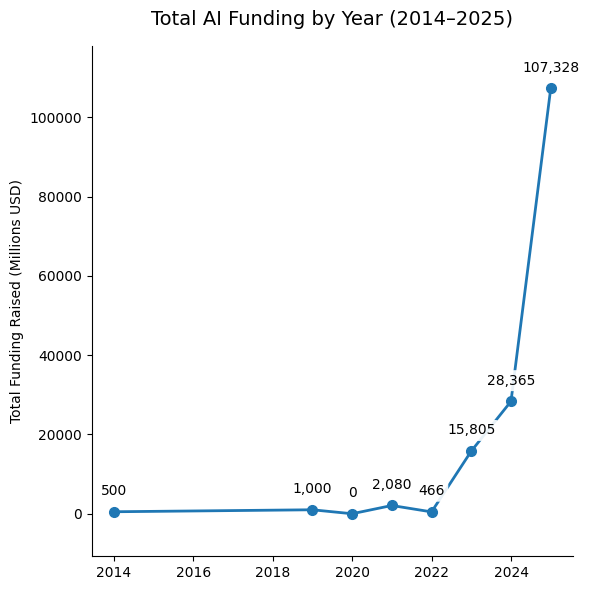

In [28]:
# Visualization 2: Total AI Funding by Year

# Aggregate funding by year

funding_by_year = (
    df.groupby('year')['amount_usd_millions']
      .sum()
      .reset_index()
)

# Create figure

plt.figure(figsize=(6,6))

# Create line plot

plt.plot(
    funding_by_year['year'],
    funding_by_year['amount_usd_millions'],
    marker='o',
    linewidth=2,
    markersize=7
)

# Add data labels with white background to prevent overlap

for x, y in zip(
    funding_by_year['year'],
    funding_by_year['amount_usd_millions']
):

    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=10,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='none',
            alpha=0.9
        )
    )

# Chart title

plt.title(
    'Total AI Funding by Year (2014–2025)',
    fontsize=14,
    pad=15
)

# Leave room above highest label

plt.margins(y=0.10)

# Axis labels

plt.ylabel('Total Funding Raised (Millions USD)')

# Remove unnecessary chart borders

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve layout

plt.tight_layout()

#save plot
plt.savefig(
    'funding_by_year.png',
    dpi=150,
    bbox_inches='tight'
)

# Display chart

plt.show()

### Interpretation

AI funding remained relatively modest between 2014 and 2022, with annual funding generally below \$3 billion. Beginning in 2023, investment activity increased substantially, reaching approximately $15.8 billion. Funding continued to accelerate in 2024 and surged to more than \$107 billion in 2025. This trend highlights the rapid growth of investor interest in artificial intelligence, particularly following the emergence of generative AI technologies.

# Visualization 3: Funding vs. Post-Money Valuation

This scatter plot examines the relationship between funding received and post-money valuation. Understanding this relationship helps determine whether companies that attract larger investments also tend to achieve higher valuations.

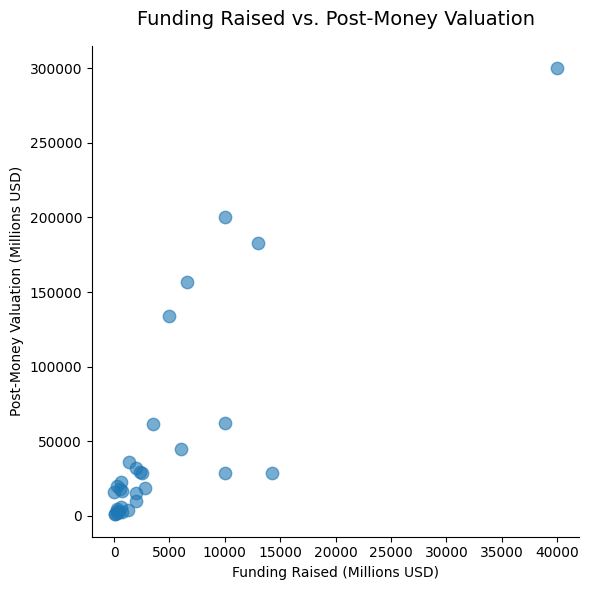

In [29]:
# Create dataset for scatter plot

scatter_data = df[
    ['amount_usd_millions',
     'post_money_valuation_millions']
].dropna()

# Create figure

plt.figure(figsize=(6,6))

# Scatter plot

plt.scatter(
    scatter_data['amount_usd_millions'],
    scatter_data['post_money_valuation_millions'],
    alpha=0.6,
    s=80
)

# Title

plt.title(
    'Funding Raised vs. Post-Money Valuation',
    fontsize=14,
    pad=15
)

# Labels

plt.xlabel('Funding Raised (Millions USD)')
plt.ylabel('Post-Money Valuation (Millions USD)')

# Remove unnecessary borders

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve layout

plt.tight_layout()

# Save figure

plt.savefig(
    'funding_vs_valuation.png',
    dpi=150,
    bbox_inches='tight'
)

# Display chart

plt.show()

### Interpretation

The scatter plot indicates a positive relationship between funding raised and post-money valuation. Companies that receive larger investments generally tend to achieve higher valuations. However, the wide spread of points suggests that valuation depends on additional factors such as market position, technological innovation, growth potential, and investor confidence.

# Conclusions

- OpenAI received substantially more funding than any other company in the dataset, raising approximately $57.9 billion between 2014 and 2025.

- AI investment increased dramatically after 2022, growing from less than $1 billion annually in earlier years to more than $107 billion in 2025.

- Companies that receive larger investments generally tend to achieve higher post-money valuations, indicating a positive relationship between funding and company value.

- The results suggest that investor confidence in artificial intelligence has accelerated rapidly, particularly following advances in generative AI technologies.